In [36]:
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

df = pd.read_csv("data/output/srilanka_retail_2020_2026_small.csv")

geo_data = gpd.read_file("data/geodata/District_geo.json")
geo_data = geo_data[['ADM2_EN', 'geometry']].rename(columns={'ADM2_EN': 'District'})

dis_df = df.groupby('District')['Total_Price_LKR'].sum().sort_values(ascending=False).reset_index()
district = geo_data.merge(dis_df, how='left', left_on='District', right_on='District')

# Drop the first row of the district GeoDataFrame
district = district.iloc[1:]

sri_lanka_map = folium.Map(location=[7.8731, 80.7718], zoom_start=7)

folium.Choropleth(
    geo_data=district,
    name='choropleth',
    data=district,
    columns=['District', 'Total_Price_LKR'],
    key_on='feature.properties.District',
    fill_color='Reds',
    fill_opacity=0.8,
    line_opacity=0.2,
    legend_name='Total Price in LKR'
).add_to(sri_lanka_map)

sri_lanka_map

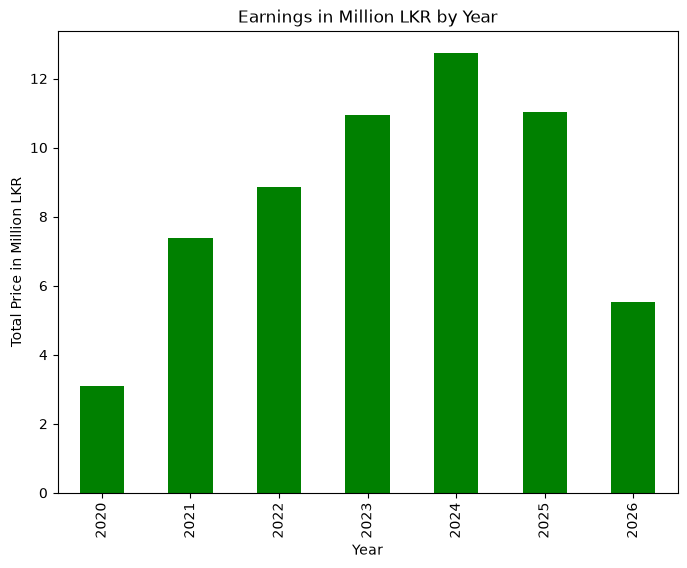

In [35]:
year_data = df.groupby('Year')['Total_Price_LKR'].sum().reset_index()
year_data['Total_Price_LKR'] = year_data['Total_Price_LKR'] / 1000000
year_data.plot(x='Year', y='Total_Price_LKR', kind='bar', title='Earnings in Million LKR by Year', xlabel='Year', ylabel='Total Price in Million LKR', legend=None, color='green', figsize=(8, 6))
plt.show()

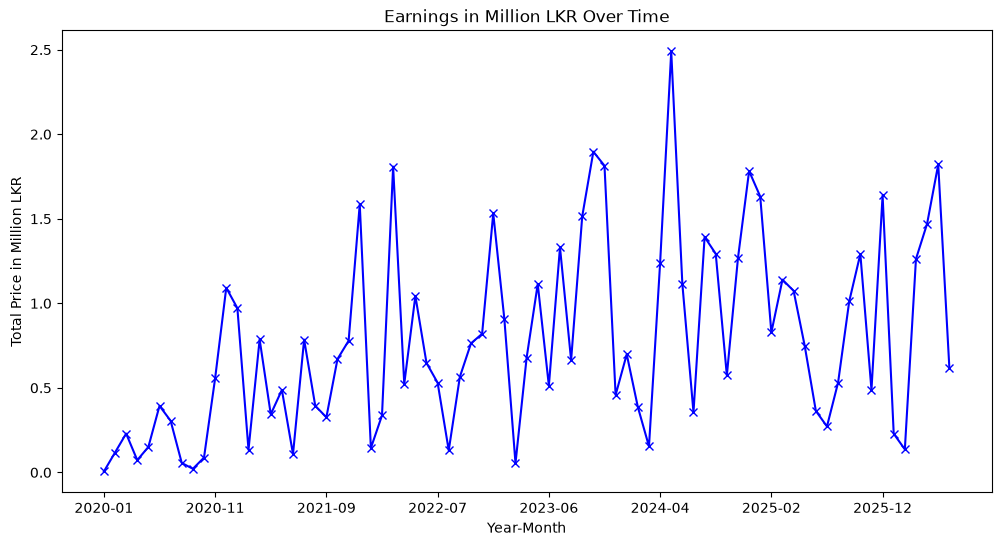

In [ ]:
# Convert invoice data to year and month
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

year_month_data = df.groupby(['Year', 'Month'])['Total_Price_LKR'].sum().reset_index()
year_month_data['YearMonth'] = year_month_data['Year'].astype(str) + '-' + year_month_data['Month'].astype(str).str.zfill(2)
year_month_data['Total_Price_LKR'] = year_month_data['Total_Price_LKR'] / 1000000
year_month_data = year_month_data[['YearMonth', 'Total_Price_LKR']]
year_month_data.plot(x='YearMonth', y='Total_Price_LKR', kind='line', title='Earnings in Million LKR Over Time',
                    xlabel='Year-Month', ylabel='Total Price in Million LKR', legend=None, color='blue', marker="x", figsize=(12, 6))
plt.show()